                    C-MAPSS
                       │
                       ↓
                 Preprocessing
                       │
                       ↓
                 30-cycle windows
                       │
             ┌─────────┴─────────┐
             ↓                   ↓
     Statistical Features     Raw Sequences
             ↓                   ↓
       Classical ML             LSTM
             ↓                   ↓
      Random Forest          RUL prediction
             │                   │
             └─────────┬─────────┘
                       ↓
                 Compare models
                       ↓
                  MAE / RMSE

In [32]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

PyTorch: 2.13.0+cpu
CUDA available: False
Using: cpu


In [34]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [35]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_data = np.load(
    PROCESSED_DIR / "train_sequences.npz"
)

val_data = np.load(
    PROCESSED_DIR / "val_sequences.npz"
)

test_data = np.load(
    PROCESSED_DIR / "test_sequences.npz"
)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

## Convert NumPy → PyTorch tensors

In [36]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [37]:
BATCH_SIZE = 128

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [38]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

___

# Build the LSTM architecture

In [39]:
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        # Representation from final timestep
        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction.squeeze(1)

In [40]:
input_size = X_train.shape[2]

print("Input features:", input_size)

Input features: 15


In [41]:
model = LSTMRegressor(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
)

model = model.to(device)

print(model)

LSTMRegressor(
  (lstm): LSTM(15, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [42]:
criterion = nn.MSELoss()

In [43]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [44]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() * X_batch.size(0)
        )

    return total_loss / len(loader.dataset)

In [45]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    predictions = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions.extend(
                outputs.cpu().numpy()
            )

            targets.extend(
                y_batch.cpu().numpy()
            )

    avg_loss = total_loss / len(
        loader.dataset
    )

    return (
        avg_loss,
        np.array(predictions),
        np.array(targets)
    )

In [46]:
EPOCHS = 30

In [47]:
history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, _, _ = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01/30 | Train Loss: 11093.5652 | Val Loss: 8594.2634
Epoch 02/30 | Train Loss: 8921.5078 | Val Loss: 6993.5554
Epoch 03/30 | Train Loss: 7493.7161 | Val Loss: 6004.0801
Epoch 04/30 | Train Loss: 6238.8649 | Val Loss: 4680.1464
Epoch 05/30 | Train Loss: 5248.2228 | Val Loss: 3885.3914
Epoch 06/30 | Train Loss: 4418.5491 | Val Loss: 3178.5131
Epoch 07/30 | Train Loss: 3753.2392 | Val Loss: 2646.0113
Epoch 08/30 | Train Loss: 3220.4878 | Val Loss: 2233.8145
Epoch 09/30 | Train Loss: 2786.0294 | Val Loss: 1906.3165
Epoch 10/30 | Train Loss: 2441.9808 | Val Loss: 1620.3001
Epoch 11/30 | Train Loss: 2159.8303 | Val Loss: 1439.1478
Epoch 12/30 | Train Loss: 1939.2591 | Val Loss: 1245.3670
Epoch 13/30 | Train Loss: 1745.6868 | Val Loss: 1148.4110
Epoch 14/30 | Train Loss: 1590.9478 | Val Loss: 1020.4680
Epoch 15/30 | Train Loss: 1449.7390 | Val Loss: 953.3521
Epoch 16/30 | Train Loss: 1339.0310 | Val Loss: 896.3438
Epoch 17/30 | Train Loss: 1248.5726 | Val Loss: 859.5802
Epoch 18/30 | Tr

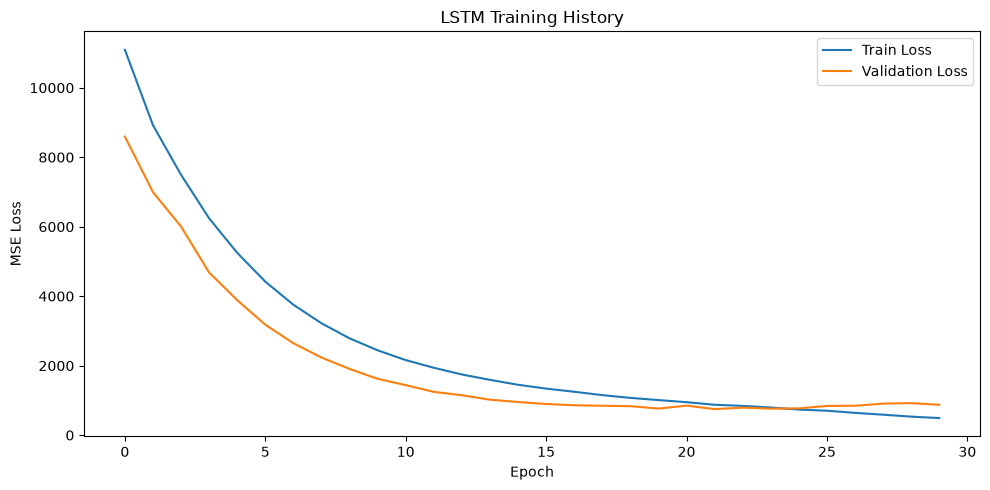

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")

plt.legend()
plt.tight_layout()
plt.show()

# Get validation predictions

In [49]:
val_loss, lstm_val_predictions, lstm_val_targets = validate(
    model,
    val_loader,
    criterion,
    device
)

In [50]:
lstm_val_mae = mean_absolute_error(
    lstm_val_targets,
    lstm_val_predictions
)

lstm_val_rmse = np.sqrt(
    mean_squared_error(
        lstm_val_targets,
        lstm_val_predictions
    )
)

print("LSTM Validation MAE:", lstm_val_mae)
print("LSTM Validation RMSE:", lstm_val_rmse)

LSTM Validation MAE: 19.71297264099121
LSTM Validation RMSE: 29.558869153021885


# Compare with our baseline

In [51]:
baseline_results = pd.read_csv(
    PROJECT_ROOT /
    "artifacts" /
    "baseline_results.csv"
)

In [52]:
lstm_result = pd.DataFrame([
    {
        "Model": "LSTM",
        "MAE": lstm_val_mae,
        "RMSE": lstm_val_rmse
    }
])

In [53]:
comparison = pd.concat(
    [
        baseline_results,
        lstm_result
    ],
    ignore_index=True
)

comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE
3,LSTM,19.712973,29.558869
0,Linear Regression,25.587166,32.807937
1,Random Forest,26.003398,37.879545
2,Mean Baseline,48.631896,57.807576


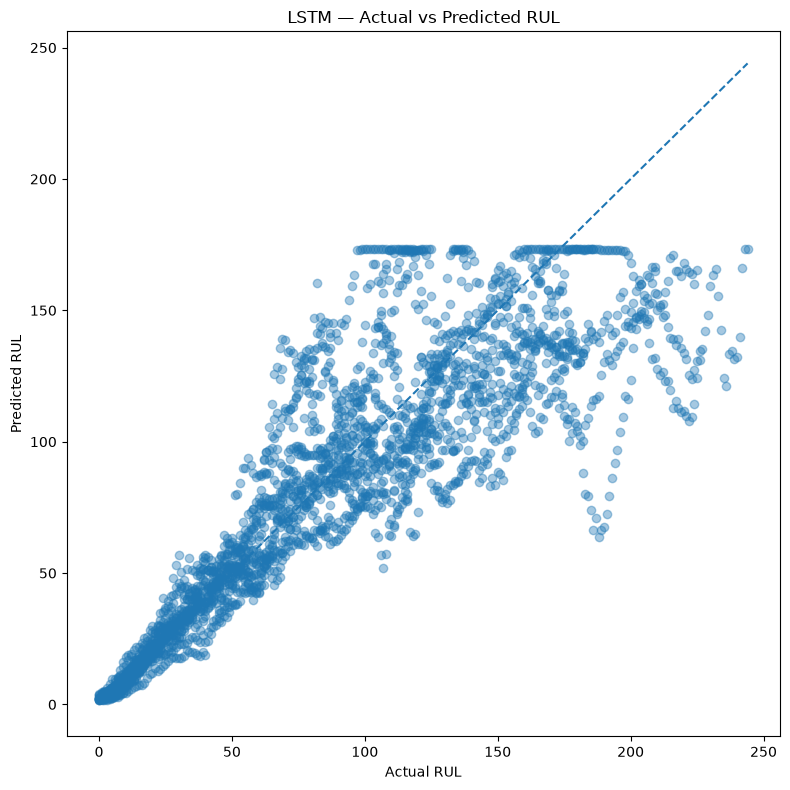

In [54]:
plt.figure(figsize=(8, 8))

plt.scatter(
    lstm_val_targets,
    lstm_val_predictions,
    alpha=0.4
)

min_value = min(
    lstm_val_targets.min(),
    lstm_val_predictions.min()
)

max_value = max(
    lstm_val_targets.max(),
    lstm_val_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("LSTM — Actual vs Predicted RUL")

plt.tight_layout()
plt.show()

In [55]:
MODEL_DIR = (
    PROJECT_ROOT /
    "artifacts" /
    "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [56]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [57]:
print(
    "GRU parameters:",
    count_parameters(model)
)

GRU parameters: 206465
